In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
amazon_df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [2]:
amazon_df

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [3]:
#PART 1
#1 Frequency tables
amazon_frequency = amazon_df["category"].value_counts()
amazon_frequency
#2 Which are the top 5 most listed product categories?
top_frequency = amazon_frequency.sort_values(ascending=False)
top_five = top_frequency[:5]
top_five

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

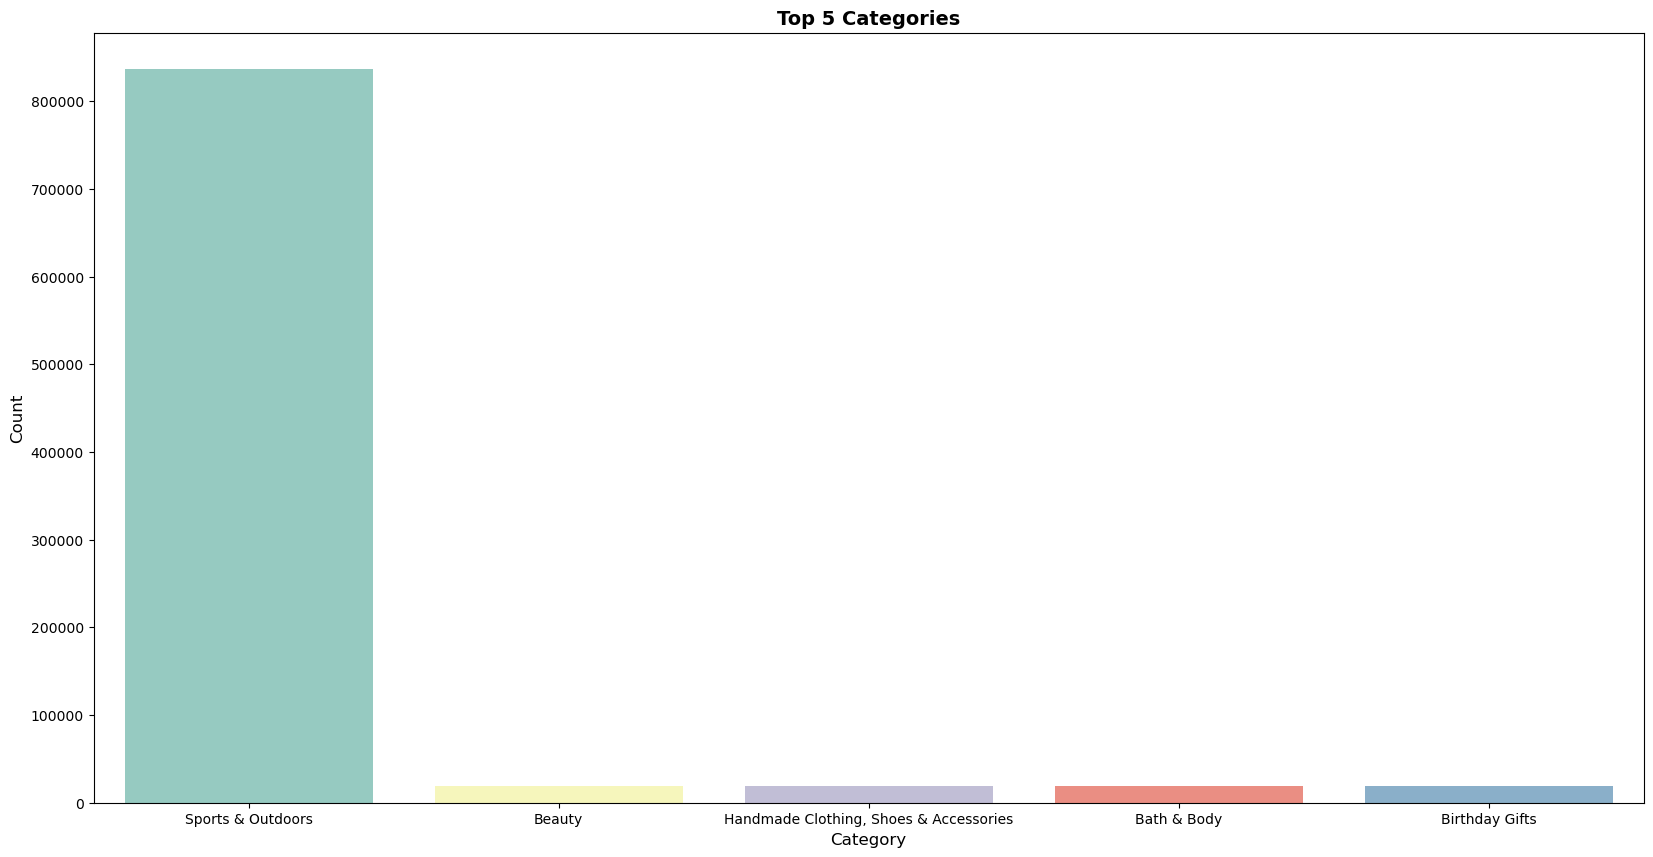

In [4]:
#2 Display the distribution of products across different categories using a bar chart.
#If you face problems understanding the chart, do it for a subset of top categories.
fig, axes = plt.subplots(figsize = (20,10))
sns.barplot(x=top_five.index, y=top_five.values, palette="Set3",hue=top_five.index, legend=False,
            ax = axes)

axes.set_xlabel("Category", fontsize=12)
axes.set_ylabel("Count", fontsize=12)
axes.set_title("Top 5 Categories", fontsize=14, fontweight="bold")
plt.show()

<Axes: ylabel='count'>

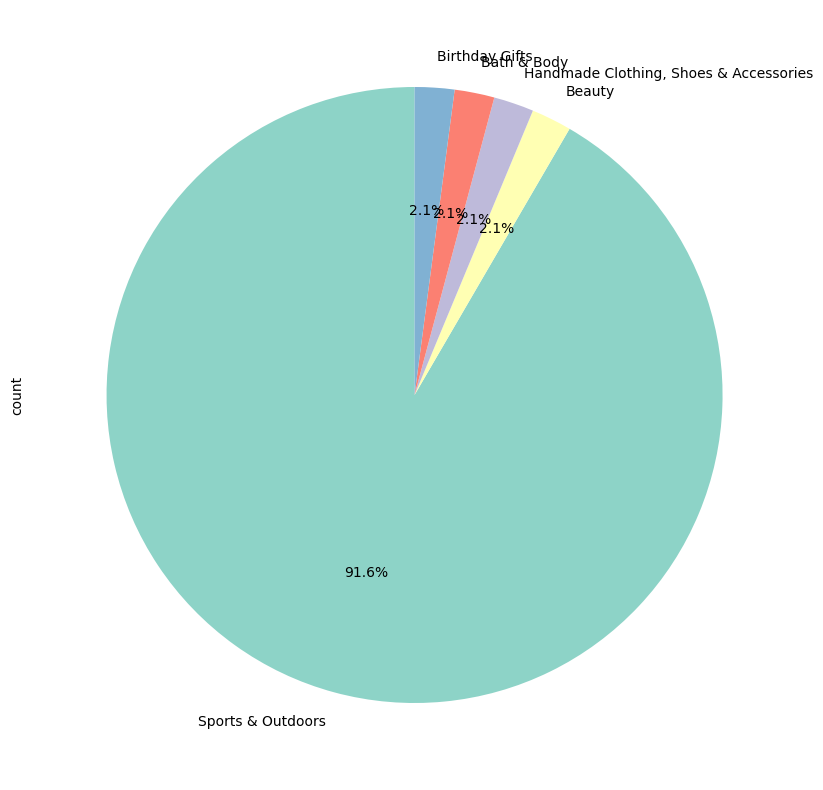

In [5]:
#For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?
plt.figure(figsize=(20,10))
top_five.plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3"))
#Sports and outdoors are the dominant categories

In [6]:
#PART 2
#Measures of centrality
#Calculate the mean, median, and mode for the price of products.
df_mean = amazon_df["price"].mean()
df_median = amazon_df["price"].median()
df_mode = amazon_df["price"].mode()
df_mean, df_median, df_mode
#What's the average price point of products listed? How does this compare with the most common price point (mode)?
#The average price is 89,24 and the mode 9,99. This means that there are very big prices pushing the mean up (regardless that 9,99 is the most common price)

(np.float64(89.24380943923663),
 np.float64(19.09),
 0    9.99
 Name: price, dtype: float64)

In [7]:
# Measures of Dispersion:
#Determine the variance, standard deviation, range, and interquartile range for product price.
df_variance = amazon_df["price"].var()
df_std = amazon_df["price"].std()
df_max = amazon_df["price"].max()
df_min = amazon_df["price"].min()
df_range = df_max - df_min
df_iqr = amazon_df["price"].quantile([0.25, 0.5, 0.75])

df_variance, df_std, df_range, df_iqr
#How varied are the product prices? Are there any indicators of a significant spread in prices?
#The prices are varied as we can see with std (meaning that the average deviation from the mean we previously saw is 345,61, which is not a small number)

(np.float64(119445.48532254907),
 np.float64(345.60886175349884),
 np.float64(100000.0),
 0.25     9.99
 0.50    19.09
 0.75    45.99
 Name: price, dtype: float64)

<Axes: xlabel='price', ylabel='Count'>

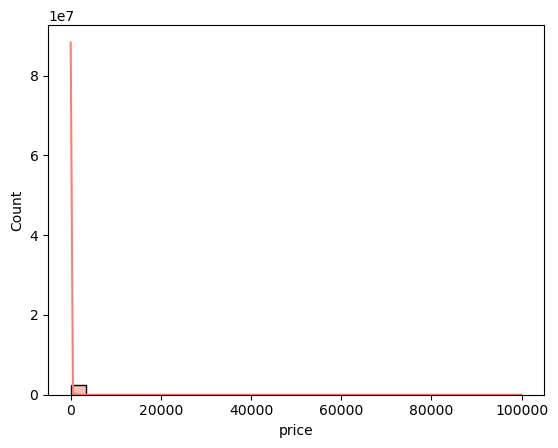

In [8]:
#Visualizations:

#Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
sns.histplot(amazon_df['price'], kde=True,bins=30, color="salmon")
#The problem is that with small bins we get an unclear hist, wth the majority of observations in the fisrt bar. Can be solved creating  bigger bins



<Axes: xlabel='price'>

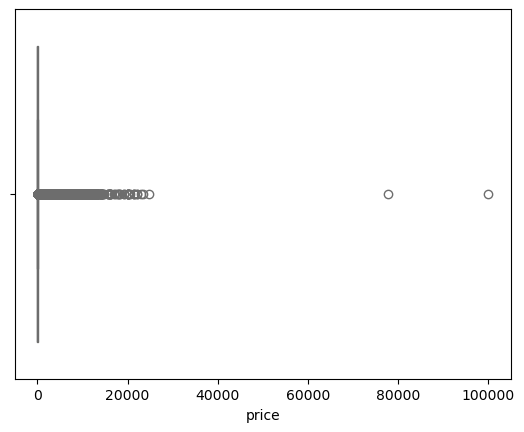

In [10]:
#Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.
sns.boxplot(x = amazon_df['price'], color="salmon")
#Yes, there are some products priced higher compared to others. There are extreme values like 100000

In [11]:
#PART 3
#1. Measures of centrality 
#Calculate the mean, median, and mode for the rating of products.
df_mean = amazon_df["stars"].mean()
df_median = amazon_df["stars"].median()
df_mode = amazon_df["stars"].mode()
df_mean, df_median, df_mode
#How do customers generally rate products? Is there a common trend?
#There are a lot of 0 ratings (is the most common rating). The median is also 0. We conclude that clients tend to rate with lower grades.

(np.float64(2.152836472966065),
 np.float64(0.0),
 0    0.0
 Name: stars, dtype: float64)

In [12]:
#2. Measures of dispersion
# Determine the variance, standard deviation, and interquartile range for product rating.
df_variance = amazon_df["stars"].var()
df_std = amazon_df["stars"].std()
df_iqr = amazon_df["stars"].quantile([0.25, 0.5, 0.75])
df_variance, df_std, df_iqr
# Are the ratings consistent, or is there a wide variation in customer feedback?
#There is a wide variation (out of 5 stars the std is 2,2)

(np.float64(4.817434029796862),
 np.float64(2.1948653785134207),
 0.25    0.0
 0.50    0.0
 0.75    4.4
 Name: stars, dtype: float64)

In [14]:
#3. Shape of the distribution
#Calculate the skewness and kurtosis for the rating column.
rating_skewness = amazon_df["stars"].skew()
rating_kurtosis = amazon_df["stars"].kurtosis()
rating_skewness, rating_kurtosis
#Are the ratings normally distributed, or do they lean towards higher or lower values?
#The positive value of skewness for the indicates that the distribution is right-skewed
#The negative kurtosis indicate a flatter shape of the distribution

(np.float64(0.08120735761080985), np.float64(-1.9260061280432985))

<Axes: xlabel='stars', ylabel='Count'>

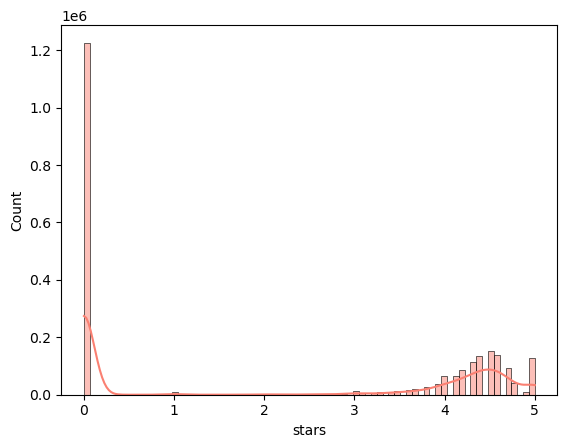

In [16]:
#4. Visualizations
#Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?
sns.histplot(amazon_df['stars'], kde=True, color="salmon")